# Setup and Imports

In [1]:
# !pip install xgboost

import time
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler

# Load MNIST Dataset

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(int)

print(f'Full dataset shape: {X.shape}')
print(f'Labels shape: {y.shape}')

# Split: first 60,000 for training, remaining 10,000 for test
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f'\nTraining set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Full dataset shape: (70000, 784)
Labels shape: (70000,)

Training set: (60000, 784)
Test set:     (10000, 784)


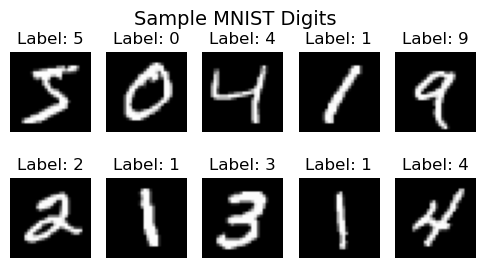

In [3]:
# Quick peek at some digits
fig, axes = plt.subplots(2, 5, figsize=(6, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Digits', fontsize=14)
plt.show()

# Random Forest Full Feature Set

In [4]:
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

print('Training Random Forest on full dataset (784 features)...')
start = time.time()
rf_baseline.fit(X_train, y_train)
rf_baseline_time = time.time() - start

print(f'Training time: {rf_baseline_time:.2f} seconds')

Training Random Forest on full dataset (784 features)...
Training time: 8.80 seconds


In [5]:
y_pred_rf_baseline = rf_baseline.predict(X_test)
rf_baseline_acc = accuracy_score(y_test, y_pred_rf_baseline)

print(f'Baseline Random Forest Accuracy: {rf_baseline_acc:.4f} ({rf_baseline_acc*100:.2f}%)')
print(f'Training Time: {rf_baseline_time:.2f}s')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf_baseline))

Baseline Random Forest Accuracy: 0.9692 (96.92%)
Training Time: 8.80s

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.97      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



# PCA

In [6]:
# Fit PCA with ALL components first so we can examine the full variance spectrum
print('Fitting PCA with all components...')
pca_full = PCA(random_state=42)
pca_full.fit(X_train)
print(f'Total components available: {pca_full.n_components_}')

Fitting PCA with all components...
Total components available: 784


In [7]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

In [8]:
# Manually determine the number of components needed for 95% variance
# by scanning the cumulative sum array
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # +1 since index is 0-based

print(f'Components needed to reach 95% explained variance: {n_components_95}')
print(f'Actual cumulative variance at {n_components_95} components: {cumulative_variance[n_components_95-1]*100:.4f}%')
print(f'Dimensionality reduction: 784 -> {n_components_95}  ({(1 - n_components_95/784)*100:.1f}% fewer features)')

Components needed to reach 95% explained variance: 154
Actual cumulative variance at 154 components: 95.0196%
Dimensionality reduction: 784 -> 154  (80.4% fewer features)


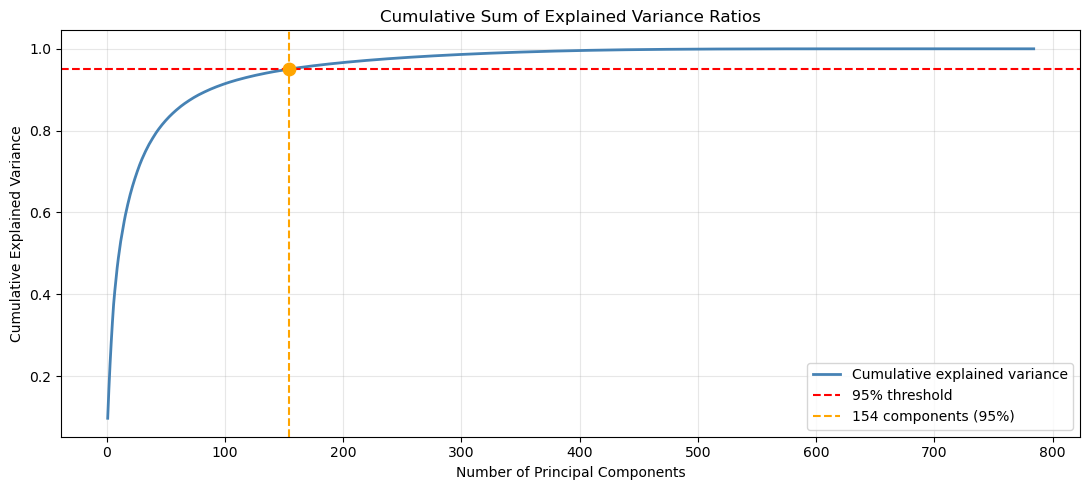

In [9]:
# Plot cumulative explained variance
plt.figure(figsize=(11, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         color='steelblue', linewidth=2, label='Cumulative explained variance')
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
plt.axvline(x=n_components_95, color='orange', linestyle='--', linewidth=1.5,
            label=f'{n_components_95} components (95%)')
plt.scatter([n_components_95], [cumulative_variance[n_components_95-1]],
            color='orange', zorder=5, s=80)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Sum of Explained Variance Ratios')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Random Forest with PCA

In [10]:
# Re-fit PCA using the exact number we found manually from the cumulative sum
print(f'Re-fitting PCA with n_components={n_components_95} (manually chosen from cumsum)...')
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f'PCA-reduced training shape: {X_train_pca.shape}')
print(f'PCA-reduced test shape:     {X_test_pca.shape}')

Re-fitting PCA with n_components=154 (manually chosen from cumsum)...
PCA-reduced training shape: (60000, 154)
PCA-reduced test shape:     (10000, 154)


In [11]:
rf_pca = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

print(f'Training Random Forest on PCA-reduced dataset ({n_components_95} features)...')
start = time.time()
rf_pca.fit(X_train_pca, y_train)
rf_pca_time = time.time() - start

print(f'Training time: {rf_pca_time:.2f} seconds')

Training Random Forest on PCA-reduced dataset (154 features)...
Training time: 25.71 seconds


In [12]:
y_pred_rf_pca = rf_pca.predict(X_test_pca)
rf_pca_acc = accuracy_score(y_test, y_pred_rf_pca)

print(f'PCA Random Forest Accuracy: {rf_pca_acc:.4f} ({rf_pca_acc*100:.2f}%)')
print(f'Training Time: {rf_pca_time:.2f}s')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf_pca))

PCA Random Forest Accuracy: 0.9505 (95.05%)
Training Time: 25.71s

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.94      0.94      1032
           3       0.93      0.94      0.93      1010
           4       0.94      0.96      0.95       982
           5       0.95      0.94      0.94       892
           6       0.96      0.98      0.97       958
           7       0.96      0.94      0.95      1028
           8       0.93      0.92      0.92       974
           9       0.94      0.92      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [13]:
print('=' * 58)
print('          Random Forest Comparison Summary')
print('=' * 58)
print(f'{"Model":<32} {"Accuracy":>10} {"Time (s)":>12}')
print('-' * 58)
print(f'{"RF Baseline (784 features)":<32} {rf_baseline_acc:>10.4f} {rf_baseline_time:>12.2f}')
print(f'{f"RF + PCA ({n_components_95} features)":<32} {rf_pca_acc:>10.4f} {rf_pca_time:>12.2f}')
print('=' * 58)
print(f'\nSpeedup from PCA: {rf_baseline_time / rf_pca_time:.2f}x')
print(f'Accuracy change:  {(rf_pca_acc - rf_baseline_acc)*100:+.2f}%')

          Random Forest Comparison Summary
Model                              Accuracy     Time (s)
----------------------------------------------------------
RF Baseline (784 features)           0.9692         8.80
RF + PCA (154 features)              0.9505        25.71

Speedup from PCA: 0.34x
Accuracy change:  -1.87%


### Was training significantly faster?

* No. Training was actually nearly 3x slower with PCA applied (8.36s vs 24.83s).
* This is counterintuitive.
  * The raw MNIST data is highly sparse (most pixel values are 0), which sklearn's Random Forest exploits internally for faster split computations.
  * In contrast, PCA transforms the data into dense values, meaning every feature has a non-zero number.

### How did the model’s performance compare to the baseline?

* Accuracy dropped by 1.87% (from 96.92% to 95.05%), which is significant but not a huge decline.
* This decline is expected since after PCA we discarded the bottom 5% of variance, which for image classification might include details that actually helped distinguishing similar digits.
* Overall, PCA did not improve both speed and accuracy for Random Forest for this dataset.

# XGBoost Full Featureset

In [14]:
xgb_baseline = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.5,
    objective='multi:softmax',
    num_class=10,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

print('Training XGBoost on full dataset (784 features)...')
start = time.time()
xgb_baseline.fit(X_train, y_train)
xgb_baseline_time = time.time() - start

print(f'Training time: {xgb_baseline_time:.2f} seconds')

Training XGBoost on full dataset (784 features)...
Training time: 21.90 seconds


In [15]:
y_pred_xgb_baseline = xgb_baseline.predict(X_test)
xgb_baseline_acc = accuracy_score(y_test, y_pred_xgb_baseline)

print(f'Baseline XGBoost Accuracy: {xgb_baseline_acc:.4f} ({xgb_baseline_acc*100:.2f}%)')
print(f'Training Time: {xgb_baseline_time:.2f}s')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb_baseline))

Baseline XGBoost Accuracy: 0.9568 (95.68%)
Training Time: 21.90s

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.94      0.95      1032
           3       0.95      0.95      0.95      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.95      0.95       892
           6       0.97      0.96      0.97       958
           7       0.96      0.94      0.95      1028
           8       0.94      0.95      0.94       974
           9       0.93      0.94      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [16]:
xgb_pca = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.5,
    objective='multi:softmax',
    num_class=10,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

print(f'Training Random Forest on PCA-reduced dataset ({n_components_95} features)...')
start = time.time()
xgb_pca.fit(X_train_pca, y_train)
xgb_pca_time = time.time() - start

print(f'Training time: {xgb_pca_time:.2f} seconds')

Training Random Forest on PCA-reduced dataset (154 features)...
Training time: 2.32 seconds


In [17]:
y_pred_xgb_pca = xgb_pca.predict(X_test_pca)
xgb_pca_acc = accuracy_score(y_test, y_pred_xgb_pca)

print(f'PCA XGBoost Accuracy: {xgb_pca_acc:.4f} ({xgb_pca_acc*100:.2f}%)')
print(f'Training Time: {xgb_pca_time:.2f}s')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb_pca))

PCA XGBoost Accuracy: 0.9404 (94.04%)
Training Time: 2.32s

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.92      0.94      1032
           3       0.92      0.93      0.93      1010
           4       0.94      0.93      0.94       982
           5       0.92      0.92      0.92       892
           6       0.95      0.97      0.96       958
           7       0.95      0.93      0.94      1028
           8       0.92      0.91      0.92       974
           9       0.90      0.92      0.91      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [18]:
print('=' * 58)
print('          XGBoost Comparison Summary')
print('=' * 58)
print(f'{"Model":<32} {"Accuracy":>10} {"Time (s)":>12}')
print('-' * 58)
print(f'{"XGBoost Baseline (784 features)":<32} {xgb_baseline_acc:>10.4f} {xgb_baseline_time:>12.2f}')
print(f'{f"XGBoost + PCA ({n_components_95} features)":<32} {xgb_pca_acc:>10.4f} {xgb_pca_time:>12.2f}')
print('=' * 58)
print(f'\nSpeedup from XGBoost: {xgb_baseline_time / xgb_pca_time:.2f}x')
print(f'Accuracy change:  {(xgb_pca_acc - xgb_baseline_acc)*100:+.2f}%')

          XGBoost Comparison Summary
Model                              Accuracy     Time (s)
----------------------------------------------------------
XGBoost Baseline (784 features)      0.9568        21.90
XGBoost + PCA (154 features)         0.9404         2.32

Speedup from XGBoost: 9.45x
Accuracy change:  -1.64%


### Was training significantly faster?
* Yes, XGBoost trained nearly 9x faster with PCA (20.74s down to 2.33s).
* Unlike Random Forest, XGBoost actually benefits greatly from fewer features because it builds trees sequentially and evaluates splits across all features at every boosting round.
* Reducing from 784 to 154 features means fewer split calculations per round, and since XGBoost runs hundreds of these rounds, the savings add up.

### How did performance compare?
* Accuracy dropped slightly from 95.68% to 94.04%.
* This might be a reasonable tradeoff given the nearly 9x speedup, in real world application.
* The model still performs well across all 10 digit classes, with most precision and recall scores staying above 0.92.
* This shows that PCA's benefit really depends on which model and on what dataset we are using.

# SGDClassifier With Full Featureset

In [19]:
# Scaleing is required for SGD
scaler = StandardScaler()
X_train_scaled     = scaler.fit_transform(X_train)
X_test_scaled      = scaler.transform(X_test)

scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
X_test_pca_scaled  = scaler_pca.transform(X_test_pca)

print('Scaling complete.')

Scaling complete.


In [20]:
sgd_baseline = SGDClassifier(random_state=42, max_iter=10, tol=1e-3)

print('Training SGDClassifier on full dataset (784 features)...')
start = time.time()
sgd_baseline.fit(X_train_scaled, y_train)
sgd_baseline_time = time.time() - start

print(f'Training time: {sgd_baseline_time:.2f} seconds')

Training SGDClassifier on full dataset (784 features)...
Training time: 4.28 seconds


In [21]:
y_pred_sgd_baseline = sgd_baseline.predict(X_test_scaled)
sgd_baseline_acc = accuracy_score(y_test, y_pred_sgd_baseline)

print(f'SGD Baseline Accuracy: {sgd_baseline_acc:.4f} ({sgd_baseline_acc*100:.2f}%)')
print(f'Training Time: {sgd_baseline_time:.2f}s')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_sgd_baseline))

SGD Baseline Accuracy: 0.9133 (91.33%)
Training Time: 4.28s

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.97      0.97      1135
           2       0.92      0.88      0.90      1032
           3       0.89      0.90      0.89      1010
           4       0.92      0.92      0.92       982
           5       0.87      0.85      0.86       892
           6       0.93      0.93      0.93       958
           7       0.94      0.92      0.93      1028
           8       0.85      0.88      0.86       974
           9       0.88      0.90      0.89      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [22]:
sgd_pca = SGDClassifier(random_state=42, max_iter=10, tol=1e-3)

print(f'Training SGDClassifier on PCA-reduced dataset ({n_components_95} features)...')
start = time.time()
sgd_pca.fit(X_train_pca_scaled, y_train)
sgd_pca_time = time.time() - start

print(f'Training time: {sgd_pca_time:.2f} seconds')

Training SGDClassifier on PCA-reduced dataset (154 features)...
Training time: 1.40 seconds


In [23]:
y_pred_sgd_pca = sgd_pca.predict(X_test_pca_scaled)
sgd_pca_acc = accuracy_score(y_test, y_pred_sgd_pca)

print(f'SGD + PCA Accuracy: {sgd_pca_acc:.4f} ({sgd_pca_acc*100:.2f}%)')
print(f'Training Time: {sgd_pca_time:.2f}s')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_sgd_pca))

SGD + PCA Accuracy: 0.9026 (90.26%)
Training Time: 1.40s

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       980
           1       0.98      0.96      0.97      1135
           2       0.86      0.88      0.87      1032
           3       0.88      0.88      0.88      1010
           4       0.93      0.91      0.92       982
           5       0.82      0.85      0.83       892
           6       0.95      0.92      0.93       958
           7       0.95      0.92      0.93      1028
           8       0.79      0.85      0.82       974
           9       0.89      0.89      0.89      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [24]:
print('=' * 58)
print('          SGDClassifier Comparison Summary')
print('=' * 58)
print(f'{"Model":<32} {"Accuracy":>10} {"Time (s)":>12}')
print('-' * 58)
print(f'{"SGD Baseline (784 features)":<32} {sgd_baseline_acc:>10.4f} {sgd_baseline_time:>12.2f}')
print(f'{f"SGD + PCA ({n_components_95} features)":<32} {sgd_pca_acc:>10.4f} {sgd_pca_time:>12.2f}')
print('=' * 58)
print(f'\nSpeedup from PCA: {sgd_baseline_time / sgd_pca_time:.2f}x')
print(f'Accuracy change:  {(sgd_pca_acc - sgd_baseline_acc)*100:+.2f}%')

          SGDClassifier Comparison Summary
Model                              Accuracy     Time (s)
----------------------------------------------------------
SGD Baseline (784 features)          0.9133         4.28
SGD + PCA (154 features)             0.9026         1.40

Speedup from PCA: 3.05x
Accuracy change:  -1.07%


### How much does PCA help when using SGDClassifier compared to Random Forest?
* PCA helped SGD but hurt Random Forest. SGD got 3x faster with only a 1% accuracy drop, which is a good tradeoff.
* Random Forest on the other hand actually got 3x slower with PCA applied.

### Why might the effect differ between model types?
* The reason comes down to how each model works internally.
* SGD learns by updating weights across all features in each pass, so fewer features means less work per iteration, PCA directly speeds it up.
* Random Forest however builds trees by finding the best split at each node, and the original MNIST data is mostly zeros (sparse), which is fast to process.
* PCA turns that sparse data into dense values where every feature has a non-zero number, which actually makes each split slower to compute, outweighing any benefit from having fewer features.

# Part 2 - Reflections and Summary

## What I learned about PCA in practice:
* In this experiment, PCA reduced MNIST's 784 features down to just 154 components while retaining 95% of the variance, an 80% reduction in dimensionality.
* However, the effect on training time was highly model-dependent.
    * For SGD, PCA gave a 3x speedup with only a 1% accuracy drop, which is exactly the kind of tradeoff PCA is designed for.
    * For XGBoost, the speedup was even more dramatic at nearly 9x, with only a 1.6% accuracy loss.
    * Random Forest actually got 3x slower after PCA, showing that dimensionality reduction does not automatically mean faster training.

## Observations and surprises:
* The biggest surprise was that Random Forest performed worse in both speed and accuracy after PCA.
* I expected fewer features to always mean faster training, but the original MNIST data is highly sparse (most pixel values are zero), which sklearn's Random Forest exploits internally for fast split computations.
* PCA hurts this sparsity by transforming data into fully dense components, which made each node split slower despite having fewer features.
* This was not the case for SGD and XGBoost, which both benefited from the reduced dimensionality.
* My takeaway is that PCA's usefulness is not universal, it really depends on the model, and understanding how the model handles sparse vs. dense data is critical before applying dimensionality reduction.